# EDA

Run after data_loading and features. Sentiment evolution cell needs features.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE    = '/content/drive/MyDrive/Social_Media_Mining_Project'
OUT_DIR = f'{BASE}/outputs/'
FIG_DIR = f'{BASE}/figures/'

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, spearmanr
from itertools import combinations

def set_all_seeds(seed=6):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
set_all_seeds(6)

Mounted at /content/drive


In [2]:
df = pd.read_parquet(f'{OUT_DIR}master_clean.parquet')
print('Loaded:', df.shape)
df.head(3)

Loaded: (49238, 30)


,id,title,score,upvote_ratio,num_comments,created_utc,subreddit,subscribers,permalink,url,...,month,hour,day_of_week,is_weekend,log_score,log_comments,norm_score,norm_comments,engagement_score,is_viral
0,1b9db8z,'Dragon Ball' Creator Akira Toryiyama Has Pass...,64352,0.95,3363,2024-03-08 08:31:22+00:00,anime,11104213,https://www.reddit.com/r/anime/comments/1b9db8...,https://x.com/DB_official_en/status/1765935471...,...,3.0,8.0,4.0,0,11.072139,8.120886,0.678672,0.724547,0.701610,0
1,jhqdgv,Kaguya-sama: Love Is War - Season 3 announced!,37983,0.98,1235,2020-10-25 14:30:48+00:00,anime,11104213,https://www.reddit.com/r/anime/comments/jhqdgv...,https://i.redd.it/7np2w8ngh7v51.png,...,10.0,14.0,6.0,1,10.544920,7.119636,0.590426,0.635216,0.612821,0
2,g9lda9,Aqua in yoga pants | Konosuba,31745,0.98,680,2020-04-28 16:45:45+00:00,anime,11104213,https://www.reddit.com/r/anime/comments/g9lda9...,https://i.redd.it/5s7s3g2bljv41.png,...,4.0,16.0,1.0,0,10.365522,6.523562,0.560398,0.582034,0.571216,0


## Engagement by post type

In [3]:
groups = [g['engagement_score'].values for _, g in df.groupby('post_type')]
stat, pval = kruskal(*groups)
print(f'Kruskal-Wallis  H={stat:.4f}  p={pval:.4e}')
if pval < 0.05:
    print('=> Significant difference in engagement across post types (p<0.05)')

pt_summary = df.groupby('post_type')['engagement_score'].agg(['mean','median','std','count'])
pt_summary.columns = ['mean','median','std','count']
pt_summary = pt_summary.sort_values('mean', ascending=False).round(4)
print('\nEngagement by post type:')
print(pt_summary)

Kruskal-Wallis  H=1978.8522  p=0.0000e+00
=> Significant difference in engagement across post types (p<0.05)

Engagement by post type:
             mean  median     std  count
post_type                               
video      0.6377  0.6753  0.1073   2074
image      0.6054  0.6207  0.1159  13879
link       0.6017  0.6371  0.1340  20171
text       0.5671  0.5663  0.1072  13114


/tmp/ipykernel_2910/2718694409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='post_type', y='engagement_score', order=order,


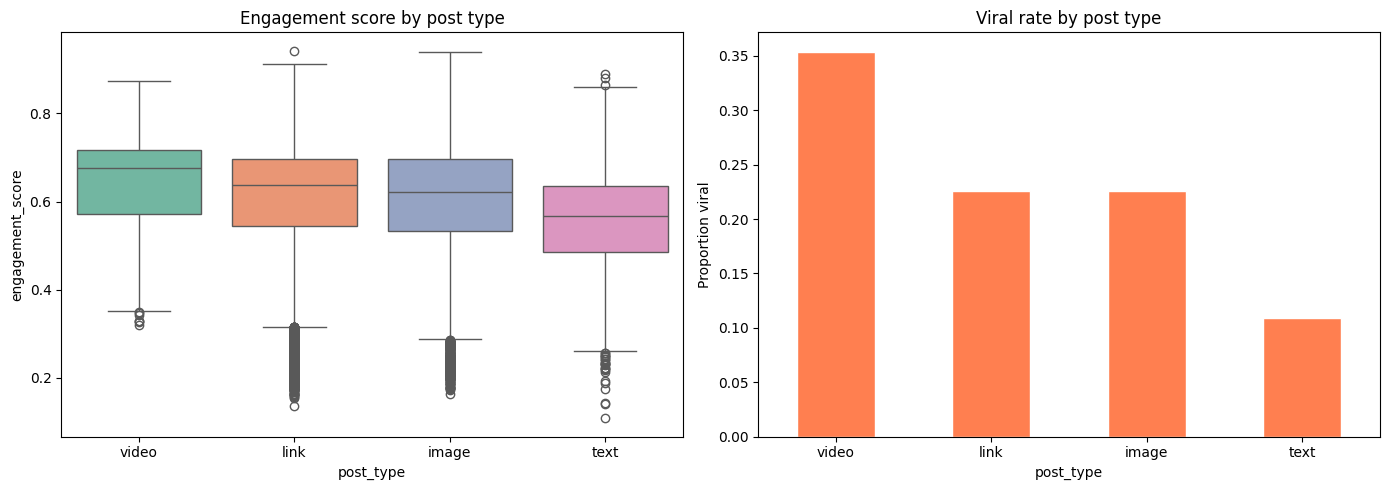

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df.groupby('post_type')['engagement_score'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='post_type', y='engagement_score', order=order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Engagement score by post type')
axes[0].set_xlabel('post_type'); axes[0].set_ylabel('engagement_score')

viral_rate = df.groupby('post_type')['is_viral'].mean().sort_values(ascending=False)
viral_rate.plot(kind='bar', color='coral', edgecolor='white', ax=axes[1])
axes[1].set_title('Viral rate by post type')
axes[1].set_xlabel('post_type'); axes[1].set_ylabel('Proportion viral')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_engagement_by_posttype.png', dpi=150, bbox_inches='tight')
plt.show()

## Temporal patterns

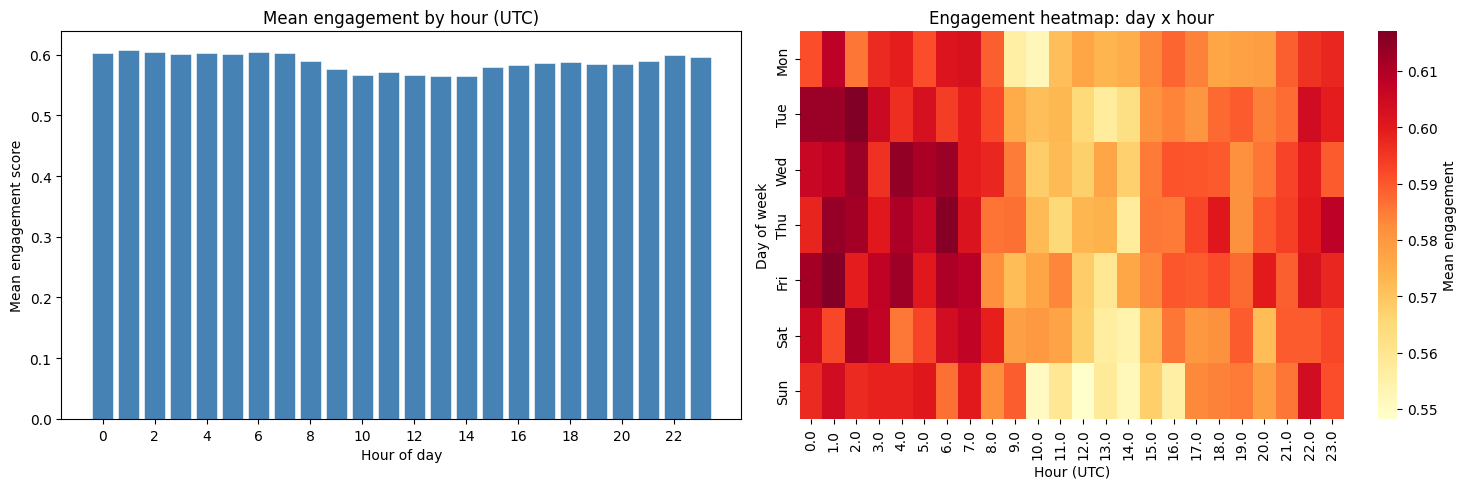

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hourly = df.groupby('hour')['engagement_score'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white', lw=0.4)
axes[0].set_title('Mean engagement by hour (UTC)')
axes[0].set_xlabel('Hour of day'); axes[0].set_ylabel('Mean engagement score')
axes[0].set_xticks(range(0, 24, 2))

dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot = df.pivot_table(values='engagement_score', index='day_of_week', columns='hour', aggfunc='mean')
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[1], yticklabels=dow_labels,
            cbar_kws={'label': 'Mean engagement'})
axes[1].set_title('Engagement heatmap: day x hour')
axes[1].set_xlabel('Hour (UTC)'); axes[1].set_ylabel('Day of week')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## Year-over-year engagement trends

      year  mean_engagement  median_score  median_comments  post_count
0   2011.0         0.249396        1218.0            226.0           1
1   2012.0         0.546404      108754.5          11439.0           2
2   2013.0         0.300504        2987.0            195.0           5
3   2014.0         0.508293       13213.0           1243.0         167
4   2015.0         0.500302       11727.0            968.0         600
5   2016.0         0.523429       14273.5            957.0        1744
6   2017.0         0.576089       32000.0           1074.0        6254
7   2018.0         0.584303       37040.0            983.0        8029
8   2019.0         0.589287       39494.0           1004.0        8218
9   2020.0         0.608281       45011.0           1043.0       11033
10  2021.0         0.614791       45338.5           1283.0        6086
11  2022.0         0.619791       44726.0           1561.0        3911
12  2023.0         0.566873       34519.5           1236.5        1580
13  20

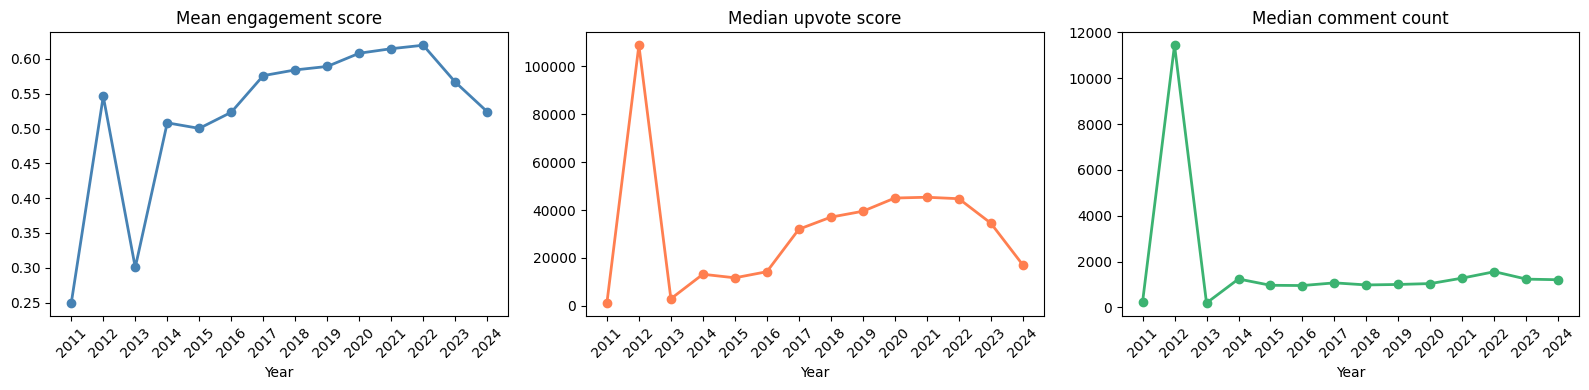

In [6]:
yearly = df.groupby('year').agg(
    mean_engagement=('engagement_score','mean'),
    median_score=('score','median'),
    median_comments=('num_comments','median'),
    post_count=('id','count')
).reset_index()
print(yearly.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title, color in zip(
    axes,
    ['mean_engagement', 'median_score', 'median_comments'],
    ['Mean engagement score', 'Median upvote score', 'Median comment count'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    ax.plot(yearly['year'], yearly[col], marker='o', color=color, lw=2)
    ax.set_title(title); ax.set_xlabel('Year')
    ax.set_xticks(yearly['year'])
    ax.set_xticklabels(yearly['year'].astype(int), rotation=45)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Top subreddits by engagement

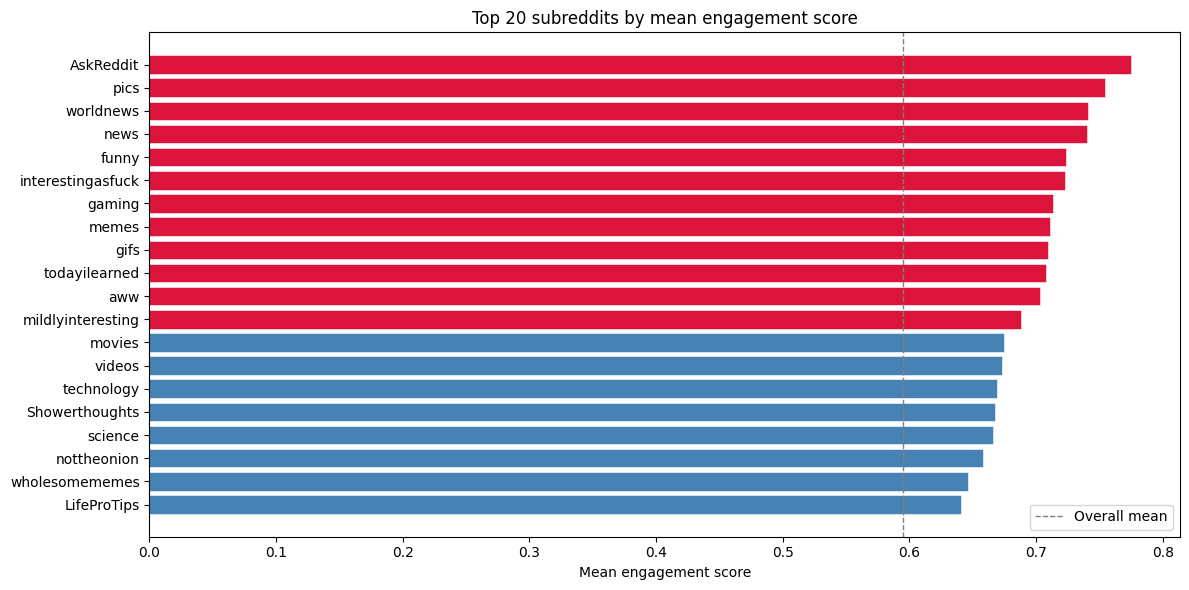

                   mean_eng  viral_rate  n_posts
subreddit                                       
AskReddit            0.7748      0.9817      985
pics                 0.7544      0.9408      996
worldnews            0.7410      0.8926      996
news                 0.7400      0.8445      997
funny                0.7235      0.7437      987
interestingasfuck    0.7227      0.6781      988
gaming               0.7136      0.6014      996
memes                0.7113      0.5567      979
gifs                 0.7097      0.5528      995
todayilearned        0.7079      0.5448      982
aww                  0.7032      0.4804      993
mildlyinteresting    0.6880      0.3186      995
movies               0.6749      0.2302      995
videos               0.6732      0.2126      997
technology           0.6688      0.1878      996
Showerthoughts       0.6673      0.1653      962
science              0.6662      0.1411      992
nottheonion          0.6582      0.1616      978
wholesomememes      

In [7]:
sub_eng = df.groupby('subreddit').agg(
    mean_eng=('engagement_score','mean'),
    viral_rate=('is_viral','mean'),
    n_posts=('id','count')
).sort_values('mean_eng', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['crimson' if v > 0.25 else 'steelblue' for v in sub_eng['viral_rate']]
ax.barh(sub_eng.index[::-1], sub_eng['mean_eng'][::-1], color=colors[::-1], edgecolor='white', lw=0.4)
ax.set_title('Top 20 subreddits by mean engagement score')
ax.set_xlabel('Mean engagement score')
ax.axvline(df['engagement_score'].mean(), color='gray', lw=1, linestyle='--', label='Overall mean')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_top_subreddits.png', dpi=150, bbox_inches='tight')
plt.show()
print(sub_eng.round(4))

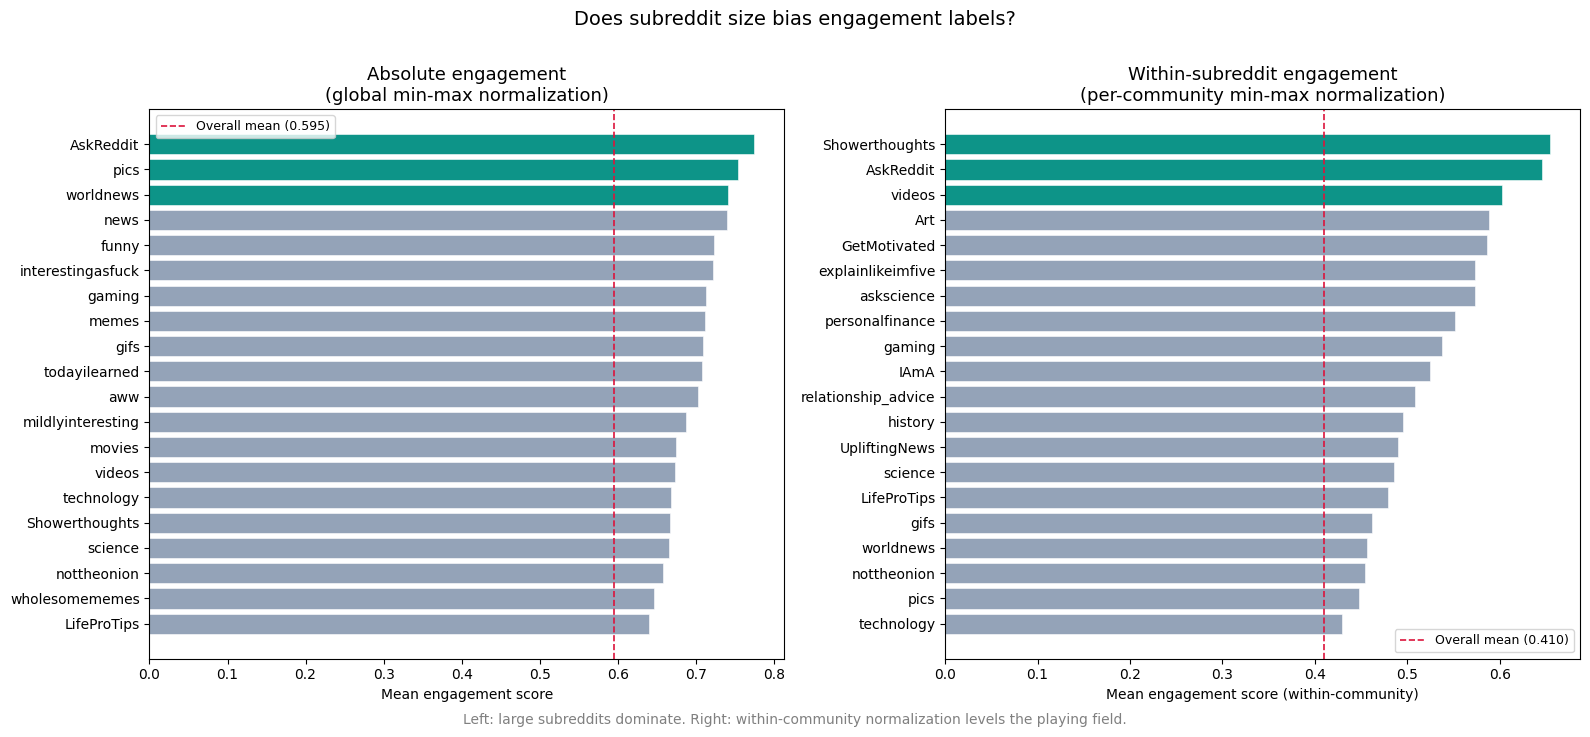

Top 10 by absolute engagement and their within-subreddit rank:
        subreddit  abs_eng  abs_rank   ws_eng  ws_rank  rank_change
        AskReddit 0.774845         1 0.645556        2           -1
             pics 0.754435         2 0.447771       19          -17
        worldnews 0.741034         3 0.456786       17          -14
             news 0.739979         4 0.343689       33          -29
            funny 0.723485         5 0.414782       23          -18
interestingasfuck 0.722712         6 0.369221       29          -23
           gaming 0.713561         7 0.537452        9           -2
            memes 0.711334         8 0.340530       35          -27
             gifs 0.709651         9 0.462225       16           -7
    todayilearned 0.707898        10 0.341534       34          -24


In [8]:
# Within-subreddit normalized engagement vs absolute engagement comparison
df['log_score_ws']    = np.log1p(df['score'])
df['log_comments_ws'] = np.log1p(df['num_comments'])

df['norm_score_ws'] = df.groupby('subreddit')['log_score_ws'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)
df['norm_comments_ws'] = df.groupby('subreddit')['log_comments_ws'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)
df['engagement_ws'] = 0.5 * df['norm_score_ws'] + 0.5 * df['norm_comments_ws']

sub_comparison = df.groupby('subreddit').agg(
    abs_eng  = ('engagement_score', 'mean'),
    ws_eng   = ('engagement_ws',    'mean'),
    n_posts  = ('id',               'count')
).reset_index().sort_values('abs_eng', ascending=False)

top20    = sub_comparison.head(20)
top20_ws = sub_comparison.sort_values('ws_eng', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_abs = ['#0D9488' if sub in ['AskReddit','pics','worldnews'] else '#94A3B8'
              for sub in top20['subreddit']]
axes[0].barh(top20['subreddit'][::-1], top20['abs_eng'][::-1],
             color=colors_abs[::-1], edgecolor='white', linewidth=0.4)
axes[0].set_title('Absolute engagement\n(global min-max normalization)', fontsize=13)
axes[0].set_xlabel('Mean engagement score')
axes[0].axvline(df['engagement_score'].mean(), color='crimson', lw=1.2,
                linestyle='--', label=f'Overall mean ({df["engagement_score"].mean():.3f})')
axes[0].legend(fontsize=9)

colors_ws = ['#0D9488' if sub in top20_ws['subreddit'].head(3).tolist() else '#94A3B8'
             for sub in top20_ws['subreddit']]
axes[1].barh(top20_ws['subreddit'][::-1], top20_ws['ws_eng'][::-1],
             color=colors_ws[::-1], edgecolor='white', linewidth=0.4)
axes[1].set_title('Within-subreddit engagement\n(per-community min-max normalization)', fontsize=13)
axes[1].set_xlabel('Mean engagement score (within-community)')
axes[1].axvline(df['engagement_ws'].mean(), color='crimson', lw=1.2,
                linestyle='--', label=f'Overall mean ({df["engagement_ws"].mean():.3f})')
axes[1].legend(fontsize=9)

fig.suptitle('Does subreddit size bias engagement labels?', fontsize=14, y=1.01)
fig.text(0.5, -0.01,
         'Left: large subreddits dominate. Right: within-community normalization levels the playing field.',
         ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_engagement_normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

abs_rank = sub_comparison.sort_values('abs_eng', ascending=False).reset_index(drop=True)
ws_rank  = sub_comparison.sort_values('ws_eng',  ascending=False).reset_index(drop=True)
abs_rank['abs_rank'] = abs_rank.index + 1
ws_rank['ws_rank']   = ws_rank.index + 1

rank_shift = abs_rank[['subreddit','abs_eng','abs_rank']].merge(
    ws_rank[['subreddit','ws_eng','ws_rank']], on='subreddit'
)
rank_shift['rank_change'] = rank_shift['abs_rank'] - rank_shift['ws_rank']
print('Top 10 by absolute engagement and their within-subreddit rank:')
print(rank_shift.sort_values('abs_rank').head(10)[
    ['subreddit','abs_eng','abs_rank','ws_eng','ws_rank','rank_change']
].to_string(index=False))

## Correlation matrix

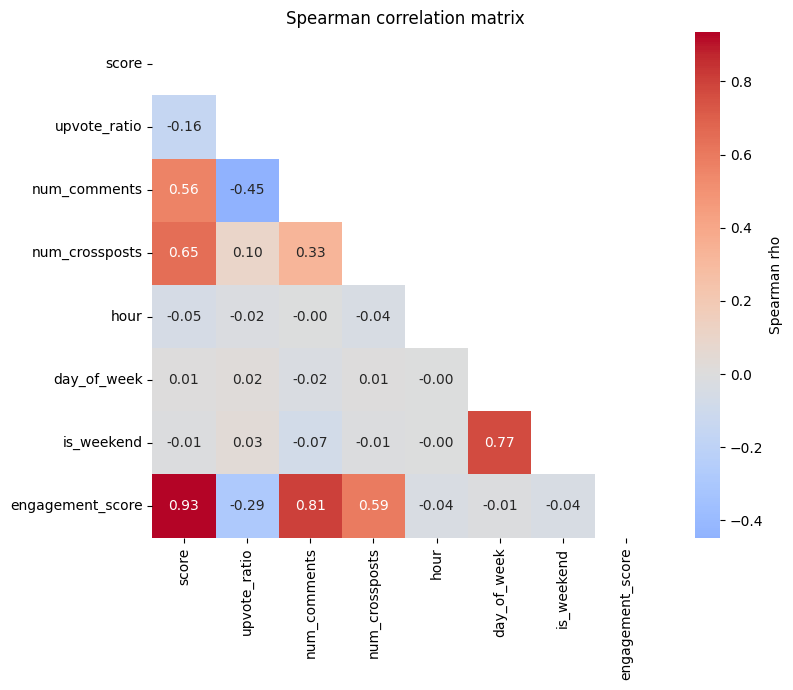


Spearman rho with engagement_score:
engagement_score    1.0000
score               0.9343
num_comments        0.8054
num_crossposts      0.5949
day_of_week        -0.0052
hour               -0.0356
is_weekend         -0.0405
upvote_ratio       -0.2902
Name: engagement_score, dtype: float64


In [9]:
numeric_cols = ['score','upvote_ratio','num_comments','num_crossposts',
                'hour','day_of_week','is_weekend','engagement_score']
spearman_matrix = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(spearman_matrix, dtype=bool))
sns.heatmap(spearman_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'label': 'Spearman rho'})
ax.set_title('Spearman correlation matrix')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_spearman_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSpearman rho with engagement_score:')
print(spearman_matrix['engagement_score'].sort_values(ascending=False).round(4))

## Crossposts vs engagement

num_crossposts vs engagement_score:  rho=0.5949  p=0.0000e+00


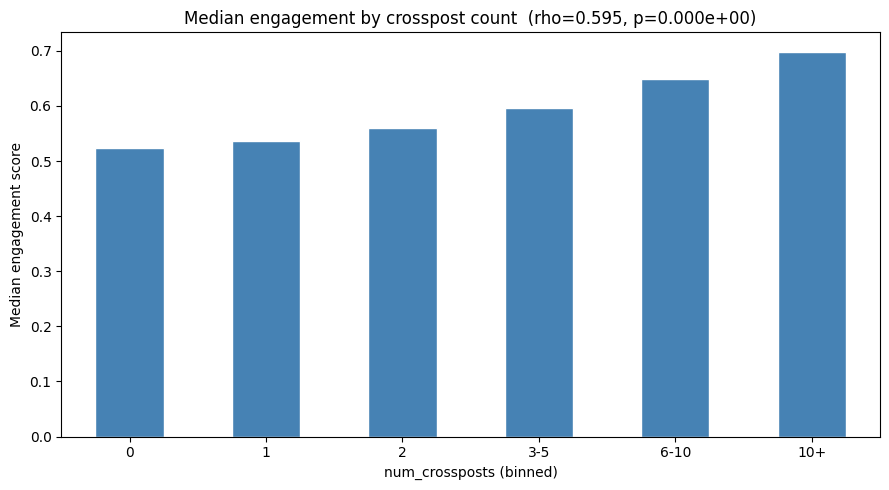

In [10]:
rho, pval = spearmanr(df['num_crossposts'], df['engagement_score'])
print(f'num_crossposts vs engagement_score:  rho={rho:.4f}  p={pval:.4e}')

df['crosspost_bin'] = pd.cut(df['num_crossposts'],
                              bins=[-1,0,1,2,5,10,999],
                              labels=['0','1','2','3-5','6-10','10+'])

fig, ax = plt.subplots(figsize=(9, 5))
cp_eng = df.groupby('crosspost_bin', observed=True)['engagement_score'].median()
cp_eng.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title(f'Median engagement by crosspost count  (rho={rho:.3f}, p={pval:.3e})')
ax.set_xlabel('num_crossposts (binned)'); ax.set_ylabel('Median engagement score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_crossposts_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

## Controversy-virality paradox

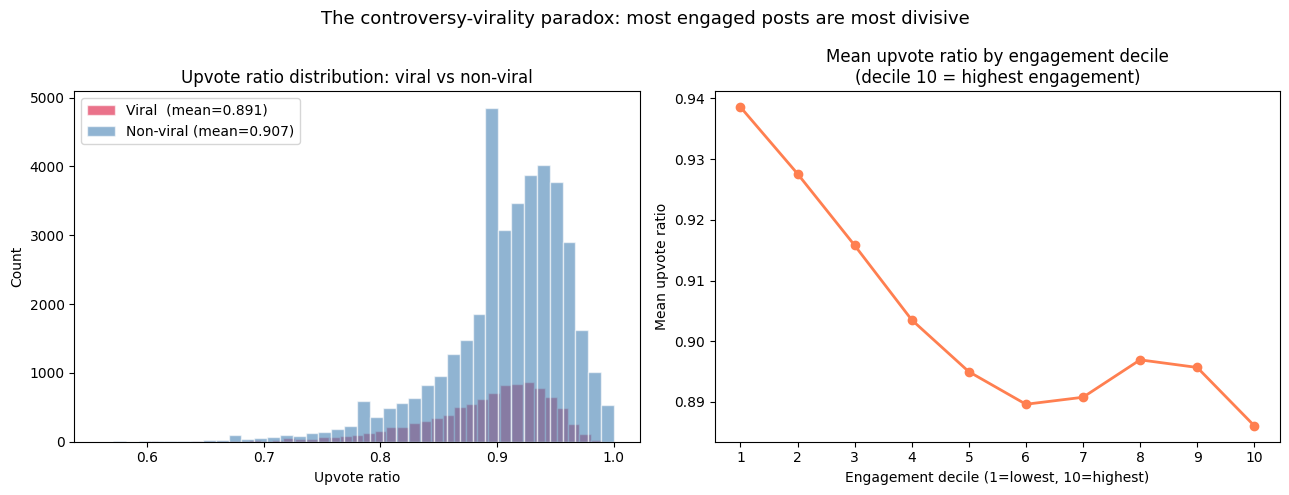

Mann-Whitney U (viral ratio < non-viral): U=159208308  p=4.2401e-168
Viral posts mean upvote ratio:     0.8909
Non-viral posts mean upvote ratio: 0.9072


In [11]:
from scipy.stats import mannwhitneyu

viral_ratio    = df[df['is_viral']==1]['upvote_ratio']
nonviral_ratio = df[df['is_viral']==0]['upvote_ratio']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(viral_ratio,    bins=40, alpha=0.6, color='crimson',
             label=f'Viral  (mean={viral_ratio.mean():.3f})', edgecolor='white')
axes[0].hist(nonviral_ratio, bins=40, alpha=0.6, color='steelblue',
             label=f'Non-viral (mean={nonviral_ratio.mean():.3f})', edgecolor='white')
axes[0].set_title('Upvote ratio distribution: viral vs non-viral')
axes[0].set_xlabel('Upvote ratio'); axes[0].set_ylabel('Count')
axes[0].legend()

df['eng_decile'] = pd.qcut(df['engagement_score'], q=10, labels=False)
decile_ratio = df.groupby('eng_decile')['upvote_ratio'].mean()
axes[1].plot(range(1, 11), decile_ratio.values, marker='o', color='coral', lw=2)
axes[1].set_title('Mean upvote ratio by engagement decile\n(decile 10 = highest engagement)')
axes[1].set_xlabel('Engagement decile (1=lowest, 10=highest)')
axes[1].set_ylabel('Mean upvote ratio')
axes[1].set_xticks(range(1, 11))

plt.suptitle('The controversy-virality paradox: most engaged posts are most divisive',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_controversy_virality_paradox.png', dpi=150, bbox_inches='tight')
plt.show()

stat, pval = mannwhitneyu(viral_ratio, nonviral_ratio, alternative='less')
print(f"Mann-Whitney U (viral ratio < non-viral): U={stat:.0f}  p={pval:.4e}")
print(f"Viral posts mean upvote ratio:     {viral_ratio.mean():.4f}")
print(f"Non-viral posts mean upvote ratio: {nonviral_ratio.mean():.4f}")

## Sentiment evolution over time

Needs `features.parquet` — run features.ipynb first.

Sentiment columns added. df shape: (49238, 40)


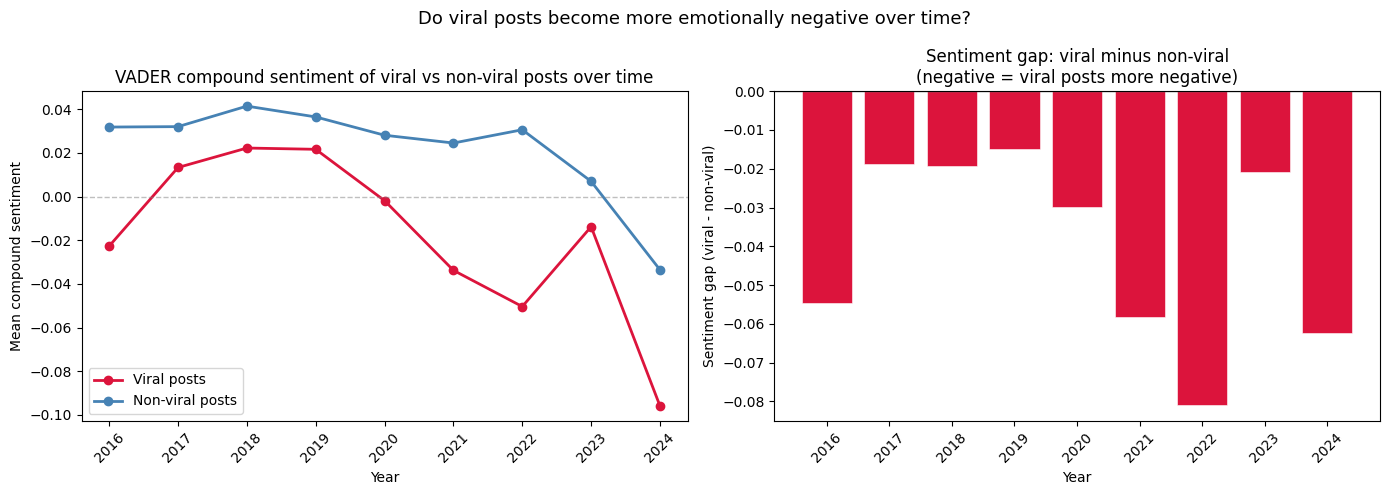

Linear slope: -0.00958 per year  (R²=0.4655  p=0.0429)


In [13]:
from scipy.stats import linregress

features_df = pd.read_parquet(f'{OUT_DIR}features.parquet')
sent_cols = ['id', 'sentiment_compound', 'sentiment_negative', 'sentiment_positive']
df = df.merge(features_df[sent_cols], on='id', how='left')
print("Sentiment columns added. df shape:", df.shape)

yearly_sentiment = (
    df[df['year'] >= 2016]
    .groupby(['year', 'is_viral'])
    .agg(
        mean_compound=('sentiment_compound', 'mean'),
        mean_negative=('sentiment_negative', 'mean'),
        mean_positive=('sentiment_positive', 'mean'),
        n=('id', 'count')
    )
    .reset_index()
)

viral_sent    = yearly_sentiment[yearly_sentiment['is_viral'] == 1].copy()
nonviral_sent = yearly_sentiment[yearly_sentiment['is_viral'] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(viral_sent['year'].astype(int), viral_sent['mean_compound'],
             marker='o', lw=2, color='crimson', label='Viral posts')
axes[0].plot(nonviral_sent['year'].astype(int), nonviral_sent['mean_compound'],
             marker='o', lw=2, color='steelblue', label='Non-viral posts')
axes[0].axhline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
axes[0].set_title('VADER compound sentiment of viral vs non-viral posts over time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean compound sentiment')
axes[0].legend()
axes[0].set_xticks(viral_sent['year'].astype(int))
axes[0].set_xticklabels(viral_sent['year'].astype(int), rotation=45)

merged = viral_sent.merge(nonviral_sent, on='year', suffixes=('_viral', '_nonviral'))
merged['sentiment_gap'] = merged['mean_compound_viral'] - merged['mean_compound_nonviral']
bar_colors = ['crimson' if g < 0 else 'steelblue' for g in merged['sentiment_gap']]
axes[1].bar(merged['year'].astype(int), merged['sentiment_gap'],
            color=bar_colors, edgecolor='white', lw=0.4)
axes[1].axhline(0, color='gray', lw=1)
axes[1].set_title('Sentiment gap: viral minus non-viral\n(negative = viral posts more negative)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Sentiment gap (viral - non-viral)')
axes[1].set_xticks(merged['year'].astype(int))
axes[1].set_xticklabels(merged['year'].astype(int), rotation=45)

plt.suptitle('Do viral posts become more emotionally negative over time?', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_sentiment_evolution_viral.png', dpi=150, bbox_inches='tight')
plt.show()

slope, intercept, r_val, p_val, _ = linregress(
    viral_sent['year'].astype(float), viral_sent['mean_compound']
)
print(f"Linear slope: {slope:.5f} per year  (R²={r_val**2:.4f}  p={p_val:.4f})")

## DiD — June 2023 API blackout

Matched to blackout list (17): ['aww', 'books', 'dataisbeautiful', 'explainlikeimfive', 'funny', 'gaming', 'gifs', 'history', 'listentothis', 'movies', 'music', 'news', 'science', 'technology', 'todayilearned', 'videos', 'worldnews']
Control group (33): ['anime', 'art', 'askreddit', 'askscience', 'creepy', 'diy', 'documentaries', 'earthporn', 'food', 'futurology', 'getmotivated', 'iama', 'interestingasfuck', 'internetisbeautiful', 'jokes', 'lifeprotips', 'memes', 'mildlyinteresting', 'nostupidquestions', 'nottheonion', 'oldschoolcool', 'personalfinance', 'pics', 'relationship_advice', 'showerthoughts', 'space', 'sports', 'television', 'tifu', 'travel', 'upliftingnews', 'wholesomememes', 'writingprompts']

=== Group statistics ===
                pre_mean  pre_median  pre_count  post_mean  post_median  \
blackout_group                                                            
blackout          0.6522      0.6819       3733     0.6163       0.6497   
control           0.5956      0.610

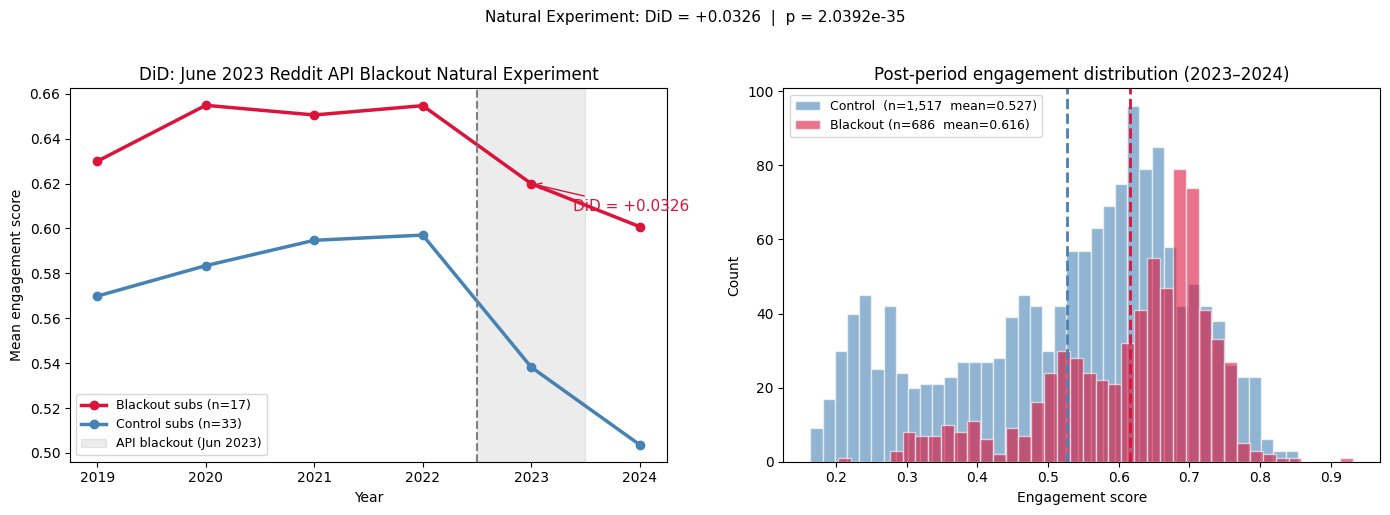

In [14]:
BLACKOUT_SUBS = {
    'funny', 'gaming', 'aww', 'todayilearned', 'science',
    'worldnews', 'videos', 'movies', 'music', 'books',
    'technology', 'news', 'gifs', 'explainlikeimfive',
    'dataisbeautiful', 'listentothis', 'history'
}

your_subs       = set(df['subreddit'].str.lower().unique())
in_blackout     = sorted(your_subs & BLACKOUT_SUBS)
not_in_blackout = sorted(your_subs - BLACKOUT_SUBS)

print(f"Matched to blackout list ({len(in_blackout)}): {in_blackout}")
print(f"Control group ({len(not_in_blackout)}): {not_in_blackout}")

PRE_START, PRE_END   = 2021, 2022
POST_START, POST_END = 2023, 2024

df['blackout_group'] = df['subreddit'].apply(
    lambda s: 'blackout' if s.lower() in BLACKOUT_SUBS else 'control'
)

pre  = df[df['year'].between(PRE_START,  PRE_END)]
post = df[df['year'].between(POST_START, POST_END)]

def group_stats(frame, label):
    return frame.groupby('blackout_group')['engagement_score'].agg(
        mean='mean', median='median', count='count'
    ).rename(columns=lambda c: f'{label}_{c}')

stats = group_stats(pre, 'pre').join(group_stats(post, 'post'))
stats['delta'] = stats['post_mean'] - stats['pre_mean']
print("\n=== Group statistics ===")
print(stats.round(4))

did_blackout = stats.loc['blackout', 'delta']
did_control  = stats.loc['control',  'delta']
did_estimate = did_blackout - did_control

print(f"\nDiD estimate (blackout - control): {did_estimate:+.4f}")

blackout_post = post[post['blackout_group'] == 'blackout']['engagement_score']
control_post  = post[post['blackout_group'] == 'control']['engagement_score']
stat, pval = mannwhitneyu(blackout_post, control_post, alternative='two-sided')
print(f"Mann-Whitney U: U={stat:.0f}  p={pval:.4e}")

# Parallel trends check
early_pre = df[df['year'].between(2019, 2020)]
late_pre  = df[df['year'].between(2021, 2022)]
pre_trends = group_stats(early_pre, 'early').join(group_stats(late_pre, 'late'))
pre_trends['pre_delta'] = pre_trends['late_mean'] - pre_trends['early_mean']
pre_div = abs(pre_trends.loc['blackout','pre_delta'] - pre_trends.loc['control','pre_delta'])
print(f"\nParallel trends divergence: {pre_div:.4f} — "
      f"{'Valid DiD design' if pre_div < 0.05 else 'WARNING: trends diverging pre-shock'}")

all_years = [2019, 2020, 2021, 2022, 2023, 2024]
yearly_group = (
    df[df['year'].isin(all_years)]
    .groupby(['year', 'blackout_group'])['engagement_score']
    .mean().unstack()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly_group.index.astype(int), yearly_group['blackout'],
             marker='o', lw=2.5, color='crimson',
             label=f'Blackout subs (n={len(in_blackout)})')
axes[0].plot(yearly_group.index.astype(int), yearly_group['control'],
             marker='o', lw=2.5, color='steelblue',
             label=f'Control subs (n={len(not_in_blackout)})')
axes[0].axvspan(2022.5, 2023.5, color='gray', alpha=0.15, label='API blackout (Jun 2023)')
axes[0].axvline(2022.5, color='gray', lw=1.5, linestyle='--')
axes[0].set_title('DiD: June 2023 Reddit API Blackout Natural Experiment')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Mean engagement score')
axes[0].set_xticks(all_years); axes[0].legend(fontsize=9)
axes[0].annotate(f'DiD = {did_estimate:+.4f}',
                 xy=(2023, yearly_group.loc[2023, 'blackout']),
                 xytext=(30, -20), textcoords='offset points',
                 fontsize=11, color='crimson',
                 arrowprops=dict(arrowstyle='->', color='crimson'))

axes[1].hist(control_post,  bins=40, alpha=0.6, color='steelblue',
             label=f'Control  (n={len(control_post):,}  mean={control_post.mean():.3f})',
             edgecolor='white')
axes[1].hist(blackout_post, bins=40, alpha=0.6, color='crimson',
             label=f'Blackout (n={len(blackout_post):,}  mean={blackout_post.mean():.3f})',
             edgecolor='white')
axes[1].axvline(control_post.mean(),  color='steelblue', lw=2, linestyle='--')
axes[1].axvline(blackout_post.mean(), color='crimson',   lw=2, linestyle='--')
axes[1].set_title('Post-period engagement distribution (2023–2024)')
axes[1].set_xlabel('Engagement score'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.suptitle(f'Natural Experiment: DiD = {did_estimate:+.4f}  |  p = {pval:.4e}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_did_blackout_natural_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

## RQ2 headline — score and comments over time

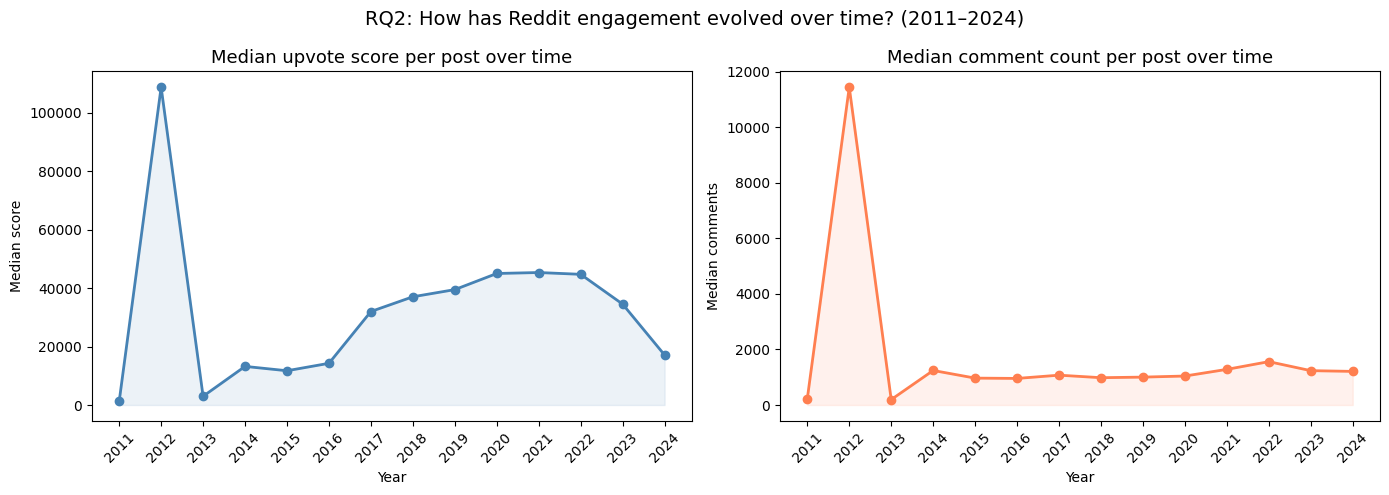

Peak median score: 108,754 in 2012


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly['year'], yearly['median_score'], marker='o', color='steelblue', lw=2)
axes[0].fill_between(yearly['year'], yearly['median_score'], alpha=0.1, color='steelblue')
axes[0].set_title('Median upvote score per post over time', fontsize=13)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Median score')
axes[0].set_xticks(yearly['year'])
axes[0].set_xticklabels(yearly['year'].astype(int), rotation=45)

axes[1].plot(yearly['year'], yearly['median_comments'], marker='o', color='coral', lw=2)
axes[1].fill_between(yearly['year'], yearly['median_comments'], alpha=0.1, color='coral')
axes[1].set_title('Median comment count per post over time', fontsize=13)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Median comments')
axes[1].set_xticks(yearly['year'])
axes[1].set_xticklabels(yearly['year'].astype(int), rotation=45)

plt.suptitle('RQ2: How has Reddit engagement evolved over time? (2011–2024)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_rq2_temporal_headline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak median score: {yearly.loc[yearly['median_score'].idxmax(), 'median_score']:,.0f} "
      f"in {yearly.loc[yearly['median_score'].idxmax(), 'year']:.0f}")

## Post-type share over time

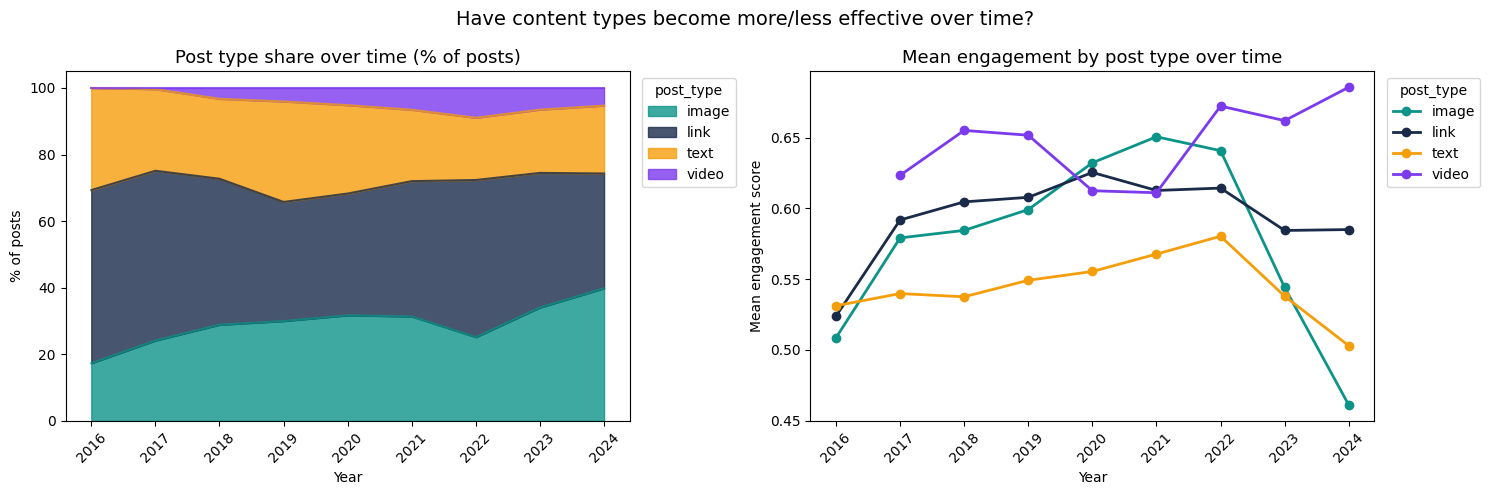

  image: 17.3% -> 34.1%
  link: 52.0% -> 40.4%
  text: 30.7% -> 19.0%
  video: 0.0% -> 6.5%


In [16]:
ptype_year = df[df['year'] >= 2016].groupby(['year', 'post_type']).size().unstack(fill_value=0)
ptype_pct = ptype_year.div(ptype_year.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ptype_pct.plot(kind='area', stacked=True, ax=axes[0],
               color=['#0D9488','#1A2B4A','#F59E0B','#7C3AED'], alpha=0.8)
axes[0].set_title('Post type share over time (% of posts)', fontsize=13)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('% of posts')
axes[0].legend(title='post_type', bbox_to_anchor=(1.01,1))
axes[0].set_xticks(ptype_pct.index)
axes[0].set_xticklabels(ptype_pct.index.astype(int), rotation=45)

ptype_eng = df[df['year'] >= 2016].groupby(['year','post_type'])['engagement_score'].mean().unstack()
ptype_eng.plot(ax=axes[1], marker='o', lw=2,
               color=['#0D9488','#1A2B4A','#F59E0B','#7C3AED'])
axes[1].set_title('Mean engagement by post type over time', fontsize=13)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Mean engagement score')
axes[1].legend(title='post_type', bbox_to_anchor=(1.01,1))
axes[1].set_xticks(ptype_eng.index)
axes[1].set_xticklabels(ptype_eng.index.astype(int), rotation=45)

plt.suptitle('Have content types become more/less effective over time?', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}02_rq5_posttype_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

for pt in ptype_pct.columns:
    y16 = ptype_pct.loc[2016.0, pt] if 2016.0 in ptype_pct.index else 0
    y23 = ptype_pct.loc[2023.0, pt] if 2023.0 in ptype_pct.index else 0
    print(f"  {pt}: {y16:.1f}% -> {y23:.1f}%")

In [17]:
print('EDA complete. Figures saved to:', FIG_DIR)

EDA complete. Figures saved to: /content/drive/MyDrive/Social_Media_Mining_Project/figures/
